# Embeddings with a pretrained AstroCLIP image encoder

[AstroCLIP](https://github.com/PolymathicAI/AstroCLIP) (Parker et al. 2024,
https://doi.org/10.1093/mnras/stae1450) CLIP-aligns a 302M-parameter DINOv2
image encoder with a 43M-parameter spectrum transformer into one shared
370M-parameter embedding space. It's too large and dependency-heavy to
reimplement natively in `astrolens` (see
`astrolens/pretrained/astroclip.py`), so this notebook uses the released
`astroclip.ckpt` checkpoint through the `astroclip` package directly,
extracting frozen **image** embeddings and running the same
cosine-similarity nearest-neighbor search as `astropt_similarity_search.ipynb`
and `aion_embeddings.ipynb`. AstroCLIP's own held-out validation set (used
for its cross-modal image/spectrum retrieval and other downstream tasks in
the reference repository) requires a ~60 GB dataset download; this notebook
avoids that by embedding a small stream of real cutouts instead, so it only
demonstrates in-modal (image-to-image) retrieval.

AstroCLIP's image encoder expects real calibrated g,r,z flux, not RGB pixel
values, so cutouts here are fetched by coordinate from the public
`legacysurvey.org/viewer/cutout.fits` service (as in `aion_embeddings.ipynb`)
and passed through `decals_to_rgb` — the exact preprocessing the AstroCLIP
README gives for running the model on cutouts outside its premade dataset —
rather than reusing `UniverseTBD/mmu_gz10`'s `rgb_image` column as model
input. Those thumbnails (and `gz10`'s labels) are only used here for display.

## Install example-only dependencies

Not part of AstroLens' core install — only needed for this example.
`astroclip` and its `dinov2` dependency both require `--no-deps` git
installs (see the [AstroCLIP README](https://github.com/PolymathicAI/AstroCLIP#installation)),
so they can't be folded into a single `pip install astrolens[astroclip]`.

In [1]:
!pip install -q datasets astropy scikit-learn matplotlib astrolens[astroclip]
!pip install -q omegaconf fvcore iopath
!pip install -q --no-deps git+https://github.com/facebookresearch/dinov2.git@2302b6bf46953431b969155307b9bed152754069
!pip install -q --no-deps git+https://github.com/PolymathicAI/AstroCLIP.git

## Imports

In [2]:
import matplotlib.pyplot as plt

import numpy as np

import torch

from sklearn.metrics.pairwise import cosine_similarity



from utils import gz10

from utils.astroclip import fetch_legacysurvey_cutouts, decals_to_rgb, compute_image_embeddings

from astrolens.pretrained.astroclip import load_pretrained_astroclip



torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

## Fetch real flux cutouts

Streams `N_EXAMPLES` `(ra, dec, rgb_image, gz10_label)` rows from
`UniverseTBD/mmu_gz10` (`utils/gz10.py`), then downloads one real 3-band
(g, r, z) Legacy Survey flux cutout per coordinate, already sized to
AstroCLIP's expected 144x144 input. Some coordinates may fall outside the
DR10 footprint and are skipped; `kept` re-aligns the surviving cutouts with
their `gz10` thumbnails/labels.

In [3]:
N_EXAMPLES = 200



examples = gz10.load_examples(N_EXAMPLES, columns=["ra", "dec", "rgb_image", "gz10_label"])

coords = [(example["ra"], example["dec"]) for example in examples]



flux, kept = fetch_legacysurvey_cutouts(coords)

examples = [examples[i] for i in kept]



images = decals_to_rgb(torch.from_numpy(flux))

images.shape

Resolving data files:   0%|          | 0/921 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/766 [00:00<?, ?it/s]

streaming gz10:   0%|          | 0/200 [00:00<?, ?ex/s]

fetching cutouts:   0%|          | 0/200 [00:00<?, ?ex/s]

torch.Size([200, 3, 144, 144])

## Load AstroCLIP and compute embeddings

`load_pretrained_astroclip` (`astrolens/pretrained/astroclip.py`) downloads
the released `astroclip.ckpt` checkpoint. `model(images, input_type="image")`
returns the image-branch embedding in AstroCLIP's shared image/spectrum
space; this notebook only computes the image side.

In [4]:
model = load_pretrained_astroclip(device=device)

embeddings = compute_image_embeddings(model, images, device)



embeddings.shape

/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'image_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['image_encoder'])`.
/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'spectrum_encoder'

embedding:   0%|          | 0/13 [00:00<?, ?batch/s]

(200, 1024)

## Similarity search

Ranks every cutout by cosine similarity to a query galaxy's embedding and
shows its nearest neighbors (displayed via `gz10`'s RGB thumbnail, not the
flux cutout fed to the model), following the same layout as
`astropt_similarity_search.ipynb` and `aion_embeddings.ipynb`.

Text(0.5, 0.98, 'Nearest neighbors of query 0')

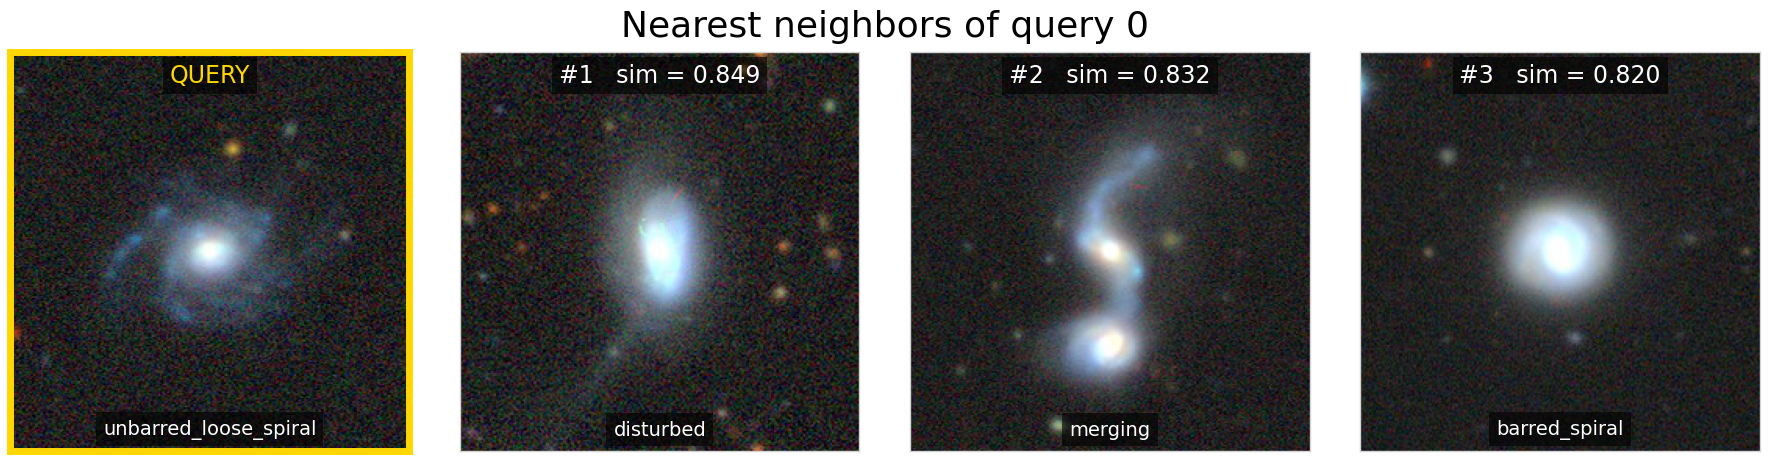

In [7]:
import io
from PIL import Image


TOP_N = 3
N_COLS = 4
QUERY_IDX = 0  # pick any position

def to_rgb(example):
    return Image.open(io.BytesIO(example["rgb_image"]["bytes"])).convert("RGB")

sims = cosine_similarity(embeddings[QUERY_IDX : QUERY_IDX + 1], embeddings)[0]
nearest = np.argsort(sims)[::-1][: TOP_N + 1]  # includes the query itself

n_rows = int(np.ceil(len(nearest) / N_COLS))
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(4.5 * N_COLS, 4.5 * n_rows), layout="constrained")

for rank, (ax, idx) in enumerate(zip(axes.flat, nearest)):
    is_query = idx == QUERY_IDX
    ax.imshow(to_rgb(examples[idx]))

    ax.text(
        0.5, 0.97,
        "QUERY" if is_query else f"#{rank}   sim = {sims[idx]:.3f}",
        transform=ax.transAxes, ha="center", va="top", fontsize=17,
        color="gold" if is_query else "white",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=5),
    )

    ax.text(
        0.5, 0.03,
        gz10.CLASS_NAMES[examples[idx]["gz10_label"]],
        transform=ax.transAxes, ha="center", va="bottom", fontsize=14,
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=5),
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set(color="gold" if is_query else "lightgray", linewidth=5 if is_query else 1)

for ax in axes.flat[len(nearest):]:
    ax.axis("off")

fig.suptitle(f"Nearest neighbors of query {QUERY_IDX}", fontsize=26)